    240000:
        Este número indica que el archivo emnist-digits-train-images-3-ubyte.gz contiene 240,000 imágenes de entrenamiento.
        Las imágenes representan dígitos del 0 al 9.

    40000:
        Este número indica que el archivo emnist-digits-test-images-idx3-ubyte.gz contiene 40,000 imágenes de prueba.
        Estas imágenes se utilizan para evaluar el modelo después de su entrenamiento.

Para emnist-letters:

    124800:
        Este número indica que el archivo emnist-letters-train-images-idx3-ubyte.gz contiene 124,800 imágenes de entrenamiento.
        Las imágenes representan letras del alfabeto (26 letras en mayúsculas y algunas adicionales, dependiendo del diseño del dataset).

    20800:
        Este número indica que el archivo emnist-letters-test-images-idx3-ubyte.gz contiene 20,800 imágenes de prueba.

LIBRERIAS

In [1]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Nadam, Adam
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, confusion_matrix

FUNCION CARGA DE DATOS

In [17]:
def cargar_mapping(ruta_archivo, dataset="digits"):
    """
    Lee el archivo de mapping y lo almacena en un diccionario.
    Si el dataset es "letters", adapta el formato.
    """
    mapping = {}
    with open(ruta_archivo, 'r') as archivo:
        for linea in archivo:
            partes = linea.strip().split()
            if dataset == "letters":
                clave, valor_upper, valor_lower = map(int, partes)
                mapping[clave] = (valor_upper, valor_lower)
            else:  # Para "digits"
                clave, valor = map(int, partes)
                mapping[clave] = valor
    return mapping

FUNCION MOSTRAR IMAGENES

In [ ]:
def mostrar_imagenes_aleatorias(imagenes, etiquetas, mapping, cantidad=20, titulo="Imágenes"):
    """
    Muestra una cantidad dada de imágenes aleatorias junto con sus etiquetas usando el mapping.
    Incluye tanto letras mayúsculas como minúsculas si el mapping contiene tuplas.
    """
    indices = random.sample(range(imagenes.shape[0]), cantidad)
    imagenes_seleccionadas = imagenes[indices]
    etiquetas_seleccionadas = etiquetas[indices]

    filas = int(np.sqrt(cantidad))
    columnas = int(np.ceil(cantidad / filas))

    plt.figure(figsize=(10, 10))
    plt.suptitle(titulo, fontsize=16)
    for i, (imagen, etiqueta) in enumerate(zip(imagenes_seleccionadas, etiquetas_seleccionadas)):
        plt.subplot(filas, columnas, i + 1)
        if etiqueta in mapping:
            if isinstance(mapping[etiqueta], tuple):  # Dataset "letters"
                etiqueta_mapeada = f"{chr(mapping[etiqueta][0])}/{chr(mapping[etiqueta][1])}"  # Uppercase/Lowercase
            else:  # Dataset "digits"
                etiqueta_mapeada = chr(mapping[etiqueta])
        else:
            etiqueta_mapeada = etiqueta
        plt.imshow(imagen.reshape(28, 28), cmap='gray')
        plt.title(f"{etiqueta_mapeada}")
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



FUNCION CREAR MODELOS

In [3]:
def crear_modelo(capas_ocultas, activacion, loss, optimizador, entradas, salidas):
    modelo = Sequential()
    modelo.add(Input(shape=entradas))  # Usar Input en lugar de input_shape en Flatten
    for capa in capas_ocultas:
        modelo.add(Dense(capa, activation=activacion))
    modelo.add(Dense(salidas, activation="softmax"))
    modelo.compile(optimizer=optimizador, loss=loss, metrics=["accuracy"])
    return modelo

FUNCION ENTREAMIENTO Y PRUEBA

In [ ]:
def reinicializar_pesos(modelo):
    for layer in modelo.layers:
        if hasattr(layer, 'kernel_initializer') and layer.kernel is not None:
            layer.kernel.assign(layer.kernel_initializer(layer.kernel.shape))
        if hasattr(layer, 'bias_initializer') and layer.bias is not None:
            layer.bias.assign(layer.bias_initializer(layer.bias.shape))
            
def entrenar_y_evaluar_modelos(modelos, x_train, y_train, x_test, y_test):
    resultados = []
    for i, modelo in enumerate(modelos):
        print(f"Entrenando Modelo MLP{i + 1}...")
        acc_totales = []
        acc_clases = []
        matrices_conf = []

        for r in range(5):
            print(f"  Repetición {r + 1}...")
            reinicializar_pesos(modelo)
            modelo.fit(x_train, y_train, epochs=5, batch_size=32, verbose=0)

            predicciones = np.argmax(modelo.predict(x_test), axis=1)
            acc_total = accuracy_score(np.argmax(y_test, axis=1), predicciones)
            matriz_conf = confusion_matrix(np.argmax(y_test, axis=1), predicciones)
            acc_clase = matriz_conf.diagonal() / matriz_conf.sum(axis=1)

            acc_totales.append(acc_total)
            acc_clases.append(acc_clase)
            matrices_conf.append(matriz_conf)

        mediana_acc = np.median(acc_totales)
        resultados.append((mediana_acc, acc_clases[-1], matrices_conf[-1], acc_totales[-1]))

    return resultados

EXPERIMENTO 1

CARGA DE DATOS DIGITS

In [30]:
ruta_digits = "./emnist-digits"
# Concatena la ruta de los archivos con la carpeta de los dígitos con os
ruta_entrenamiento_imagenes = os.path.join(ruta_digits, "emnist-digits-train-images-idx3-ubyte.gz")
ruta_entrenamiento_etiquetas = os.path.join(ruta_digits, "emnist-digits-train-labels-idx1-ubyte.gz")
ruta_prueba_imagenes = os.path.join(ruta_digits, "emnist-digits-test-images-idx3-ubyte.gz")
ruta_prueba_etiquetas = os.path.join(ruta_digits, "emnist-digits-test-labels-idx1-ubyte.gz")
ruta_mapping = os.path.join(ruta_digits, "emnist-digits-mapping.txt")

x_entrenamiento, y_entrenamiento = cargar_datos(ruta_entrenamiento_imagenes, ruta_entrenamiento_etiquetas)
x_prueba, y_prueba = cargar_datos(ruta_prueba_imagenes, ruta_prueba_etiquetas)

mapping = cargar_mapping(ruta_mapping, "digits")

MOSTRAR IMAGENES

In [ ]:
mostrar_imagenes_aleatorias(x_entrenamiento, y_entrenamiento, mapping, cantidad=20, titulo="Imágenes del conjunto de entrenamiento")
mostrar_imagenes_aleatorias(x_prueba, y_prueba, mapping, cantidad=20, titulo="Imágenes del conjunto de prueba")

CREACION MODELOS

In [ ]:
shape_entrada = (x_entrenamiento.shape[1], )
numero_clases = len(np.unique(y_entrenamiento))

y_entrenamiento_categorico = to_categorical(y_entrenamiento, num_classes=numero_clases)
y_prueba_categorico = to_categorical(y_prueba, num_classes=numero_clases)

parametros_mlp1_exp1 = {'capas_ocultas': [256, 128], 'activacion': 'swish', 'loss': 'categorical_crossentropy'}
parametros_mlp2_exp1 = {'capas_ocultas': [256, 128, 64], 'activacion': 'relu', 'loss': 'categorical_crossentropy'}
parametros_mlp3_exp1 = {'capas_ocultas': [512, 256, 128], 'activacion': 'relu', 'loss': 'categorical_crossentropy'}

MLP1_exp1 = crear_modelo(capas_ocultas=parametros_mlp1_exp1['capas_ocultas'], 
                         activacion=parametros_mlp1_exp1['activacion'], 
                         loss=parametros_mlp1_exp1['loss'], 
                         optimizador=Nadam(learning_rate=0.0003), 
                         entradas=shape_entrada, 
                         salidas=numero_clases)

MLP2_exp1 = crear_modelo(capas_ocultas=parametros_mlp2_exp1['capas_ocultas'], 
                         activacion=parametros_mlp2_exp1['activacion'], 
                         loss=parametros_mlp2_exp1['loss'], 
                         optimizador=Adam(learning_rate=0.0002), 
                         entradas=shape_entrada, 
                         salidas=numero_clases)

MLP3_exp1 = crear_modelo(capas_ocultas=parametros_mlp3_exp1['capas_ocultas'], 
                         activacion=parametros_mlp3_exp1['activacion'], 
                         loss=parametros_mlp3_exp1['loss'], 
                         optimizador=Adam(learning_rate=0.0002), 
                         entradas=shape_entrada, 
                         salidas=numero_clases)

ENTRENAMIENTO Y PRUEBA MODELOS

In [13]:
resultados = entrenar_y_evaluar_modelos([MLP1_exp1, MLP2_exp1, MLP3_exp1], x_entrenamiento, y_entrenamiento_categorico, x_prueba, y_prueba_categorico)


Entrenando Modelo MLP1...
  Repetición 1...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 885us/step
  Repetición 2...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 897us/step
  Repetición 3...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step
  Repetición 4...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 913us/step
  Repetición 5...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step
Entrenando Modelo MLP2...
  Repetición 1...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 802us/step
  Repetición 2...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 814us/step
  Repetición 3...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step
  Repetición 4...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 811us/step
  Repetición 5...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step
Entrenando Modelo MLP3...
  Repetición 1...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step
  Repetición 2...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step
  Repetición 3...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
  Repetición 4...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 5...
1250/1250 ━━━━━━━━━━━━━━━━

RESULTADOS


Modelo MLP1:
Mediana 5 iteraciones: 0.9880
Accuracy por clase: [0.98775 0.99275 0.98675 0.98325 0.988   0.98875 0.99025 0.9915  0.9835
 0.988  ]


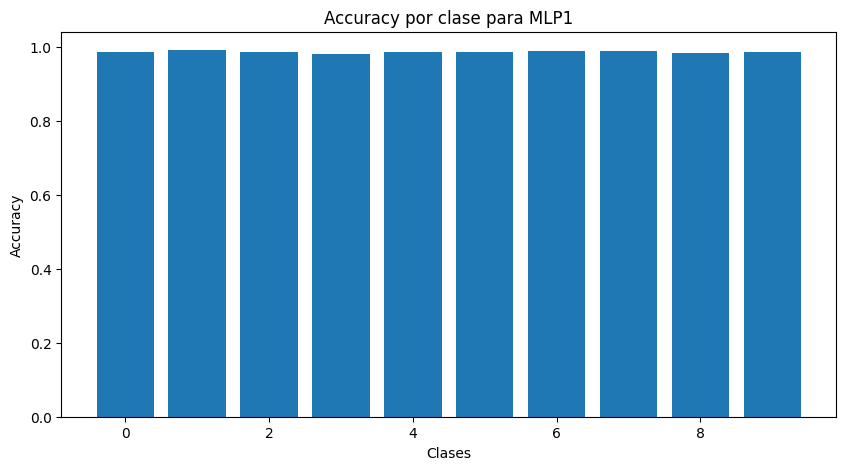

Accuracy total del modelo: 0.98805
Matriz de confusión:
[[3951    2    7    3    2    7    8    0   14    6]
 [   1 3971    6    3    4    1    3    3    7    1]
 [   2    4 3947   15    4    5    1    6   13    3]
 [   2    0   13 3933    0   20    0   11   17    4]
 [   2    6    3    0 3952    2    5    5    5   20]
 [   3    0    1   14    1 3955    5    1   13    7]
 [   9    3    1    1    2   15 3961    0    8    0]
 [   0    2    3    0    5    1    0 3966    3   20]
 [   3    8    8   11    5   13    3    5 3934   10]
 [   0    4    1    5    7    6    1   12   12 3952]]

Modelo MLP2:
Mediana 5 iteraciones: 0.9806
Accuracy por clase: [0.99275 0.9915  0.9795  0.97725 0.98075 0.972   0.99075 0.985   0.96425
 0.9795 ]


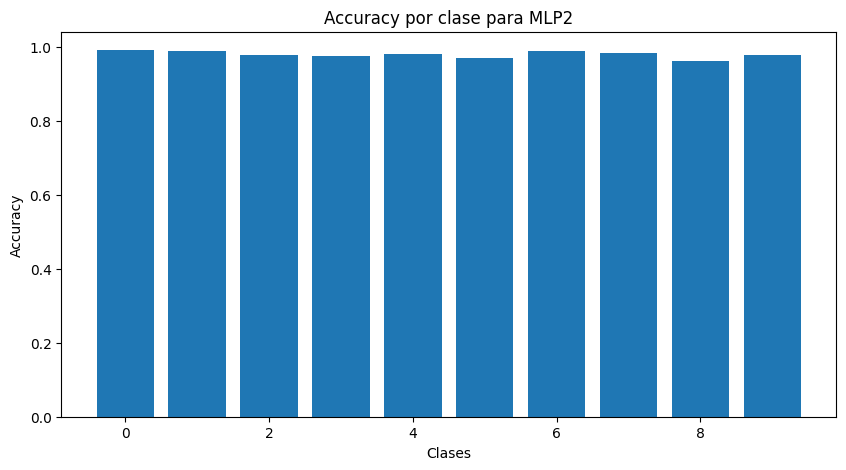

Accuracy total del modelo: 0.981325
Matriz de confusión:
[[3971    1    3    3    4    3    8    0    6    1]
 [   1 3966    8    3    6    2    3    3    7    1]
 [   8    5 3918   22   11    2    8    7   15    4]
 [   6    3   26 3909    3   15    0   11   18    9]
 [   3    5    9    0 3923    2   14    5    5   34]
 [  14    1    3   41    4 3888   19    4   19    7]
 [  13    3    3    2    7    5 3963    0    4    0]
 [   4    5   11    3    6    1    0 3940    4   26]
 [  16   19   17   30    7   13    7   12 3857   22]
 [   3    4    1   14   18    9    2   22    9 3918]]

Modelo MLP3:
Mediana 5 iteraciones: 0.9862
Accuracy por clase: [0.995   0.9915  0.985   0.9765  0.98475 0.975   0.9905  0.98675 0.98125
 0.98825]


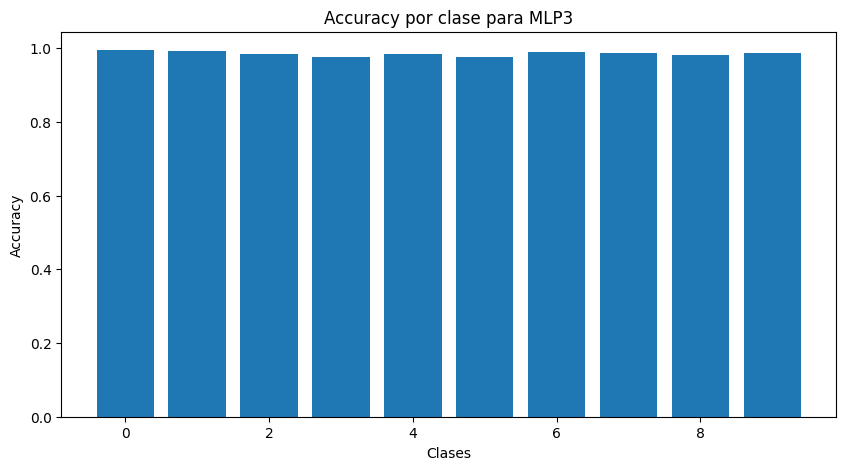

Accuracy total del modelo: 0.98545
Matriz de confusión:
[[3980    0    4    1    2    1    3    0    7    2]
 [   2 3966   10    2    5    0    2    3    9    1]
 [   9    4 3940   10    8    0    3    6   17    3]
 [   7    0   22 3906    0   14    1   11   32    7]
 [   4    5    8    1 3939    0    7    2    4   30]
 [  16    0    2   32    3 3900   15    2   22    8]
 [  15    3    3    1    7    4 3962    0    5    0]
 [   2    2   10    0    6    1    0 3947    3   29]
 [  10    5    7   13    5    6    7    5 3925   17]
 [   2    3    2    8    9    7    0    8    8 3953]]

Mediana Diggits: 0.9862


In [15]:
median_diggits = []
for i, (mediana_acc, acc_clase, matriz_conf, acc_totales) in enumerate(resultados):
    print(f"\nModelo MLP{i + 1}:")
    print(f"Mediana 5 iteraciones: {mediana_acc:.4f}")
    print(f"Accuracy por clase: {acc_clase}")

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(acc_clase)), acc_clase)
    plt.xlabel("Clases")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy por clase para MLP{i + 1}")
    plt.show()

    print(f"Accuracy total del modelo: {acc_totales}")
    print(f"Matriz de confusión:\n{matriz_conf}")
    median_diggits.append(mediana_acc)

print(f"\nMediana Diggits: {np.median(median_diggits):.4f}")


EXPRIMENTO 2

CARGAR DATOS

In [54]:
ruta_letters = "./emnist-letters"
# Concatena la ruta de los archivos con la carpeta de las letras con os
ruta_entrenamiento_imagenes = os.path.join(ruta_letters, "emnist-letters-train-images-idx3-ubyte.gz")
ruta_entrenamiento_etiquetas = os.path.join(ruta_letters, "emnist-letters-train-labels-idx1-ubyte.gz")
ruta_prueba_imagenes = os.path.join(ruta_letters, "emnist-letters-test-images-idx3-ubyte.gz")
ruta_prueba_etiquetas = os.path.join(ruta_letters, "emnist-letters-test-labels-idx1-ubyte.gz")
ruta_mapping = os.path.join(ruta_letters, "emnist-letters-mapping.txt")

x_entrenamiento, y_entrenamiento = cargar_datos(ruta_entrenamiento_imagenes, ruta_entrenamiento_etiquetas)
x_prueba, y_prueba = cargar_datos(ruta_prueba_imagenes, ruta_prueba_etiquetas)

mapping = cargar_mapping(ruta_mapping, "letters")


MOSTRAR IMÁGENES

In [ ]:
mostrar_imagenes_aleatorias(x_entrenamiento, y_entrenamiento, mapping, cantidad=20, titulo="Imágenes del conjunto de entrenamiento")
mostrar_imagenes_aleatorias(x_prueba, y_prueba, mapping, cantidad=20, titulo="Imágenes del conjunto de prueba")

CREACION MODELOS

In [ ]:
shape_entrada = (x_entrenamiento.shape[1], )
numero_clases = len(np.unique(y_entrenamiento))

y_entrenamiento = y_entrenamiento - 1
y_prueba = y_prueba - 1

y_entrenamiento_categorico = to_categorical(y_entrenamiento, num_classes=numero_clases)
y_prueba_categorico = to_categorical(y_prueba, num_classes=numero_clases)


parametros_mlp1_exp2 = {'capas_ocultas': [256, 128], 'activacion': 'swish', 'loss': 'categorical_crossentropy'}
parametros_mlp2_exp2 = {'capas_ocultas': [256, 128, 64], 'activacion': 'relu', 'loss': 'categorical_crossentropy'}
parametros_mlp3_exp2 = {'capas_ocultas': [512, 256, 128], 'activacion': 'relu', 'loss': 'categorical_crossentropy'}

MLP1_exp2 = crear_modelo(capas_ocultas=parametros_mlp1_exp1['capas_ocultas'], 
                         activacion=parametros_mlp1_exp1['activacion'], 
                         loss=parametros_mlp1_exp1['loss'], 
                         optimizador=Nadam(learning_rate=0.0003), 
                         entradas=shape_entrada, 
                         salidas=numero_clases)

MLP2_exp2 = crear_modelo(capas_ocultas=parametros_mlp2_exp1['capas_ocultas'], 
                         activacion=parametros_mlp2_exp1['activacion'], 
                         loss=parametros_mlp2_exp1['loss'], 
                         optimizador=Adam(learning_rate=0.0002), 
                         entradas=shape_entrada, 
                         salidas=numero_clases)

MLP3_exp2 = crear_modelo(capas_ocultas=parametros_mlp3_exp1['capas_ocultas'], 
                         activacion=parametros_mlp3_exp1['activacion'], 
                         loss=parametros_mlp3_exp1['loss'], 
                         optimizador=Adam(learning_rate=0.0002), 
                         entradas=shape_entrada, 
                         salidas=numero_clases)

ENTRENAMIENTO Y PRUEBA MODELOS

In [56]:
entrenar_y_evaluar_modelos([MLP1_exp2, MLP2_exp2, MLP3_exp2], x_entrenamiento, y_entrenamiento_categorico, x_prueba, y_prueba_categorico)

Entrenando Modelo MLP1...
  Repetición 1...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 2...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 3...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
  Repetición 4...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 902us/step
  Repetición 5...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 924us/step
Entrenando Modelo MLP2...
  Repetición 1...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step
  Repetición 2...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 802us/step
  Repetición 3...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step
  Repetición 4...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 823us/step
  Repetición 5...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 798us/step
Entrenando Modelo MLP3...
  Repetición 1...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step
  Repetición 2...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step
  Repetición 3...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 801us/step
  Repetición 4...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 975us/step
  Repetición 5...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 860us/step


[(np.float64(0.87875),
  array([0.865  , 0.9075 , 0.9275 , 0.84625, 0.9075 , 0.875  , 0.675  ,
         0.8925 , 0.68   , 0.8975 , 0.86125, 0.78   , 0.94   , 0.88875,
         0.95375, 0.945  , 0.82375, 0.87375, 0.93   , 0.92875, 0.9125 ,
         0.86125, 0.9375 , 0.92   , 0.9025 , 0.925  ]),
  array([[692,   3,   6,  11,   9,   3,   5,  12,   0,   1,   3,   0,   0,
            7,   5,   4,  24,   2,   0,   0,   5,   0,   2,   2,   0,   4],
         [  7, 726,   0,   6,   7,   1,   4,  17,   4,   2,   1,   6,   0,
            3,   3,   1,   2,   3,   0,   0,   0,   0,   0,   0,   0,   7],
         [  3,   2, 742,   1,  23,   0,   1,   0,   1,   0,   0,   4,   0,
            1,   6,   1,   1,   5,   3,   2,   1,   0,   0,   1,   0,   2],
         [ 10,  20,   1, 677,   0,   0,   1,   4,   1,  12,   1,   1,   0,
            2,  47,   6,   4,   1,   4,   2,   1,   0,   0,   0,   3,   2],
         [  7,   5,  30,   0, 726,   1,   3,   0,   1,   1,   0,   2,   1,
            0,   3,   2,  

RESULTADOS


Modelo MLP1:
Mediana 5 iteraciones: 0.9880
Accuracy por clase: [0.98775 0.99275 0.98675 0.98325 0.988   0.98875 0.99025 0.9915  0.9835
 0.988  ]


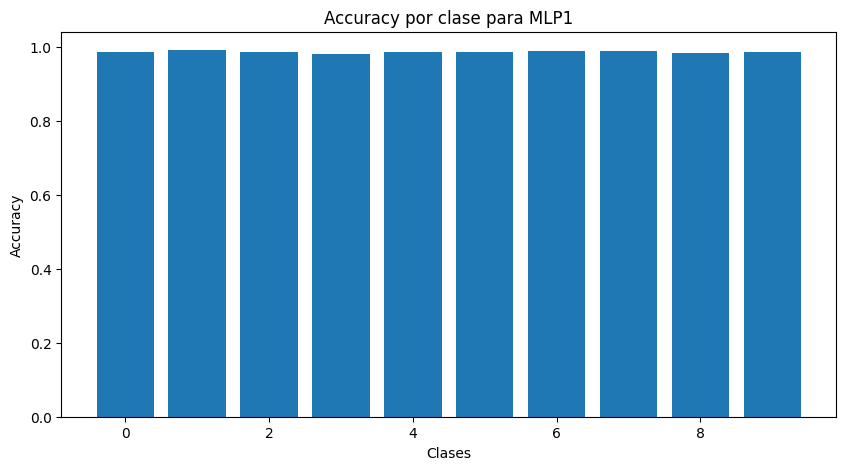

Accuracy total del modelo: 0.98805
Matriz de confusión:
[[3951    2    7    3    2    7    8    0   14    6]
 [   1 3971    6    3    4    1    3    3    7    1]
 [   2    4 3947   15    4    5    1    6   13    3]
 [   2    0   13 3933    0   20    0   11   17    4]
 [   2    6    3    0 3952    2    5    5    5   20]
 [   3    0    1   14    1 3955    5    1   13    7]
 [   9    3    1    1    2   15 3961    0    8    0]
 [   0    2    3    0    5    1    0 3966    3   20]
 [   3    8    8   11    5   13    3    5 3934   10]
 [   0    4    1    5    7    6    1   12   12 3952]]

Modelo MLP2:
Mediana 5 iteraciones: 0.9806
Accuracy por clase: [0.99275 0.9915  0.9795  0.97725 0.98075 0.972   0.99075 0.985   0.96425
 0.9795 ]


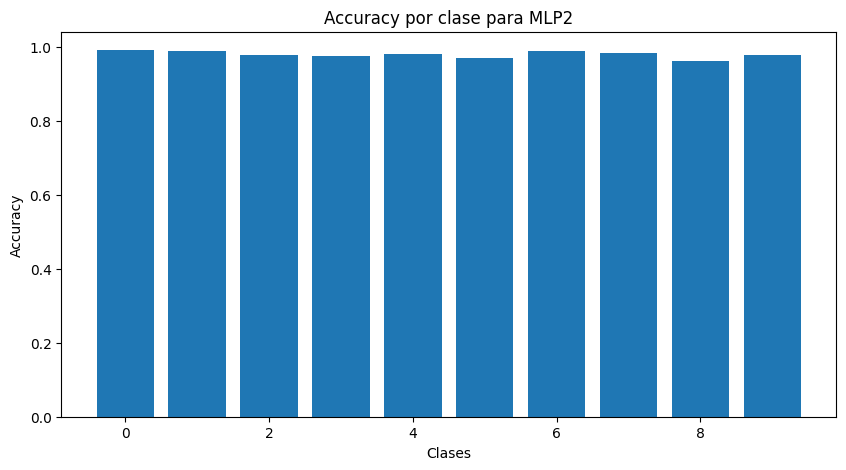

Accuracy total del modelo: 0.981325
Matriz de confusión:
[[3971    1    3    3    4    3    8    0    6    1]
 [   1 3966    8    3    6    2    3    3    7    1]
 [   8    5 3918   22   11    2    8    7   15    4]
 [   6    3   26 3909    3   15    0   11   18    9]
 [   3    5    9    0 3923    2   14    5    5   34]
 [  14    1    3   41    4 3888   19    4   19    7]
 [  13    3    3    2    7    5 3963    0    4    0]
 [   4    5   11    3    6    1    0 3940    4   26]
 [  16   19   17   30    7   13    7   12 3857   22]
 [   3    4    1   14   18    9    2   22    9 3918]]

Modelo MLP3:
Mediana 5 iteraciones: 0.9862
Accuracy por clase: [0.995   0.9915  0.985   0.9765  0.98475 0.975   0.9905  0.98675 0.98125
 0.98825]


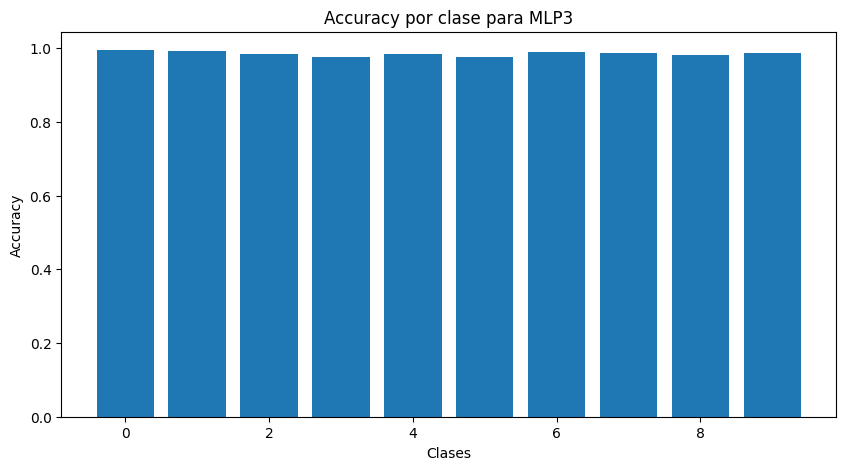

Accuracy total del modelo: 0.98545
Matriz de confusión:
[[3980    0    4    1    2    1    3    0    7    2]
 [   2 3966   10    2    5    0    2    3    9    1]
 [   9    4 3940   10    8    0    3    6   17    3]
 [   7    0   22 3906    0   14    1   11   32    7]
 [   4    5    8    1 3939    0    7    2    4   30]
 [  16    0    2   32    3 3900   15    2   22    8]
 [  15    3    3    1    7    4 3962    0    5    0]
 [   2    2   10    0    6    1    0 3947    3   29]
 [  10    5    7   13    5    6    7    5 3925   17]
 [   2    3    2    8    9    7    0    8    8 3953]]

Mediana Letters: 0.9862


In [58]:
median_diggits = []
for i, (mediana_acc, acc_clase, matriz_conf, acc_totales) in enumerate(resultados):
    print(f"\nModelo MLP{i + 1}:")
    print(f"Mediana 5 iteraciones: {mediana_acc:.4f}")
    print(f"Accuracy por clase: {acc_clase}")

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(acc_clase)), acc_clase)
    plt.xlabel("Clases")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy por clase para MLP{i + 1}")
    plt.show()

    print(f"Accuracy total del modelo: {acc_totales}")
    print(f"Matriz de confusión:\n{matriz_conf}")
    median_diggits.append(mediana_acc)

print(f"\nMediana Letters: {np.median(median_diggits):.4f}")